## Evaluation pipeline for the microlane experiment

In [1]:
# Imports of the Core Packages
from tqdm.notebook import tqdm
import random
from pathlib import Path

In [2]:
# Import custom libraries located at different folder location + configs
from microlane.utils.create_settings import create_settings
from microlane.utils.experiment import Experiment
from microlane.utils.loaders import load_dataset, load_model
from microlane.utils.load_config import load_config
from microlane.augmentors.augmentor import Augmentor
from microlane.schemas.prediction import Prediction

In [3]:
config = load_config()

### Experiment Settings

In [4]:
INFERENCE_VIS_NUMBER = 5
SAMPLE_NUMBER = 75
MODEL = "ufld"
DATASET = "tusimple"
AUGMENTATION_TYPE = "lighting_b"
EXPERIMENT_NAME = f"{MODEL}_{DATASET}_{AUGMENTATION_TYPE}"
OUTPUT_LOCATION = "/home/suyog/desktop/projects/microlane/results/testing"


In [5]:
_preset = config.data.augmentation.presets[AUGMENTATION_TYPE]

AUGMENTATION_SETTINGS = {
    "blur":        _preset["blur"],
    "motion_blur": _preset["motion_blur"],
    "zoom":        _preset["zoom"],
    "rotation":    _preset["rotation"],
    "lighting":    _preset["lighting"],
}

### Pre Processing Part

In [6]:
## Load the Corresponding Model and the dataset based on given settings

data  = load_dataset(DATASET, SAMPLE_NUMBER)

model = load_model(MODEL)

auggie = Augmentor()

experiment = Experiment(base_dir=Path(OUTPUT_LOCATION))


Config(pipeline=PipelineConfig(name='Microlane', version='1.0.0', description='Evaluating how well modern lane detection models hold up when deployed on small-scale 1/10 RC cars', default_port=8000), data=DataConfig(datasets=DatasetsConfig(tusimple=DatasetConfig(name='tusimple', path=PosixPath('/home/suyog/assets/datasets/TuSimple/TUSimple'), annotation_file=PosixPath('/home/suyog/assets/datasets/TuSimple/test_label_new.json'), enabled=True), custom_dataset=DatasetConfig(name='custom_dataset', path=PosixPath('/home/suyog/desktop/projects/microlane/results/custom_dataset'), annotation_file=PosixPath('/home/suyog/desktop/projects/microlane/results/custom_dataset/annotations.xml'), enabled=True)), augmentation=AugmentationConfig(ranges=AugmentationRangesConfig(motion_blur_range=(0.0, 0.1), lighting_range=(-1.0, 1.0), blur_range=(0.0, 1.0), zoom_range=(1.0, 3), rotation_range=(0.0, 360.0)), presets={'normal': AugmentationPreset(blur=0.0, rotation=0.0, zoom=1.0, lighting=0.0, motion_blur=0.

### Models and Datasets Loaded, Now Processing Part

In [7]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

item = data[0]
print(f"Image Path   : {item.image_path}")
print(f"h_samples    : {item.h_samples}")
print(f"lanes        : {item.lanes}")

Total items: 75

Image Path   : /home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492626760788443246_0/20.jpg
h_samples    : [160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330
 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510
 520 530 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690
 700 710]
lanes        : [[  -2   -2   -2   -2   -2   -2   -2   -2   -2   -2  648  636  626  615
   605  595  585  575  565  554  545  536  526  517  508  498  489  480
   470  461  452  442  433  424  414  405  396  386  377  368  359  349
   340  331  321  312  303  293  284  275  265  256  247  237  228  219]
 [  -2   -2   -2   -2   -2   -2   -2   -2   -2   -2  681  692  704  716
   728  741  754  768  781  794  807  820  834  847  860  873  886  900
   913  926  939  952  966  979  992 1005 1018 1032 1045 1058 1071 1084
  1098 1111 1124 1137 1150 1164 1177 1190 1203 1216 1230 1243 1256 1269]
 [  -2   -2   -2   -2   -2   -2   -2

In [8]:
numbers = [random.randint(0, SAMPLE_NUMBER - 1) for _ in range(INFERENCE_VIS_NUMBER)]

In [9]:
settings = create_settings(
    inference_vis_number=INFERENCE_VIS_NUMBER,
    sample_number=SAMPLE_NUMBER,
    model=MODEL,
    dataset=DATASET,
    augmentation_type=AUGMENTATION_TYPE,
    output_path=str(experiment.folder),
    experiment_name=EXPERIMENT_NAME,
)

### Looping through all the testing examples

  0%|          | 0/75 [00:00<?, ?it/s]

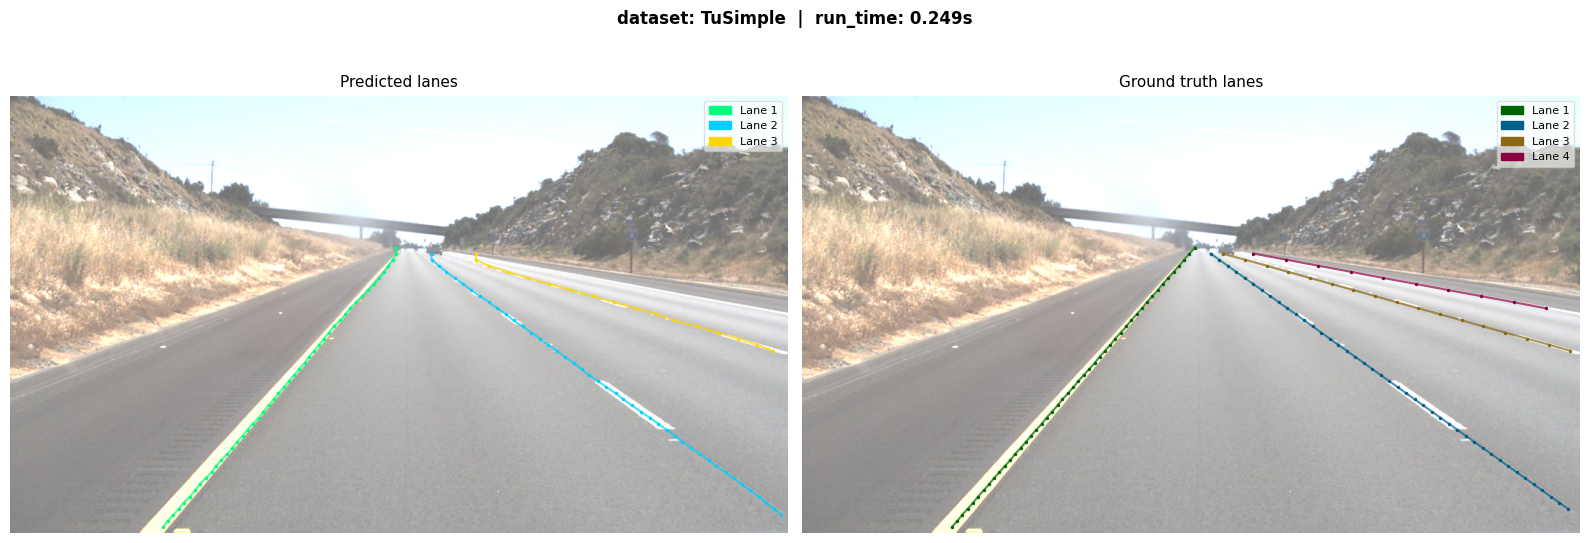

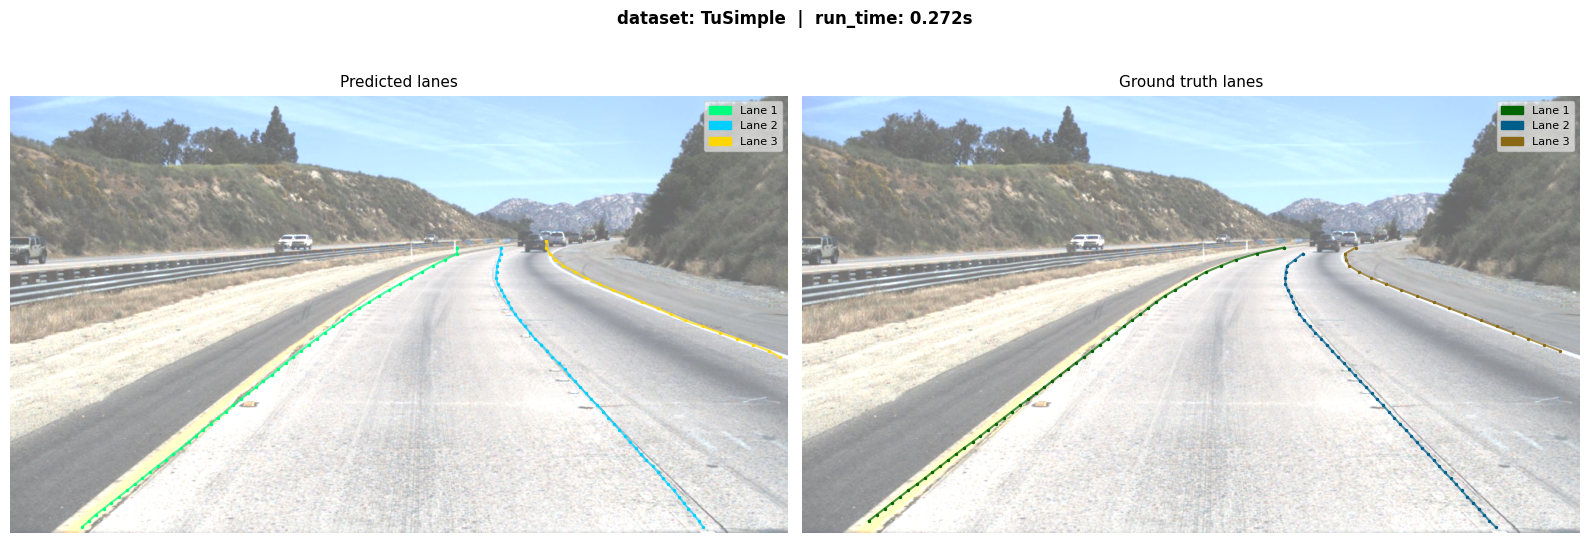

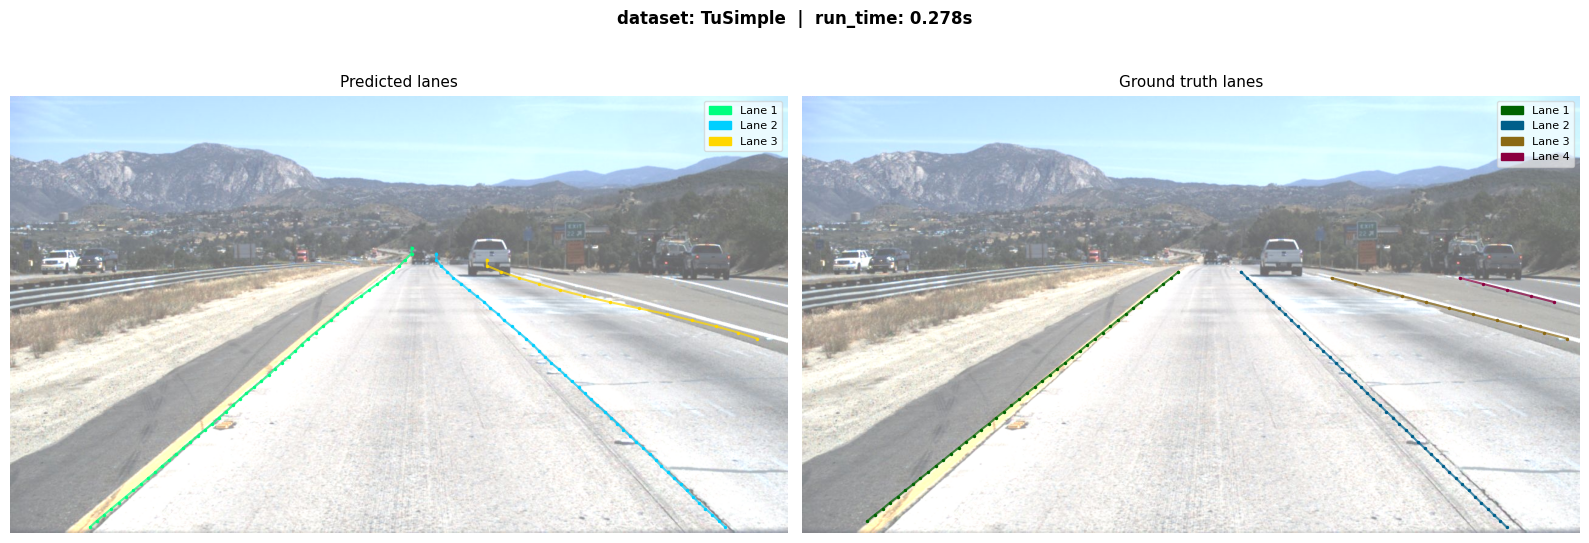

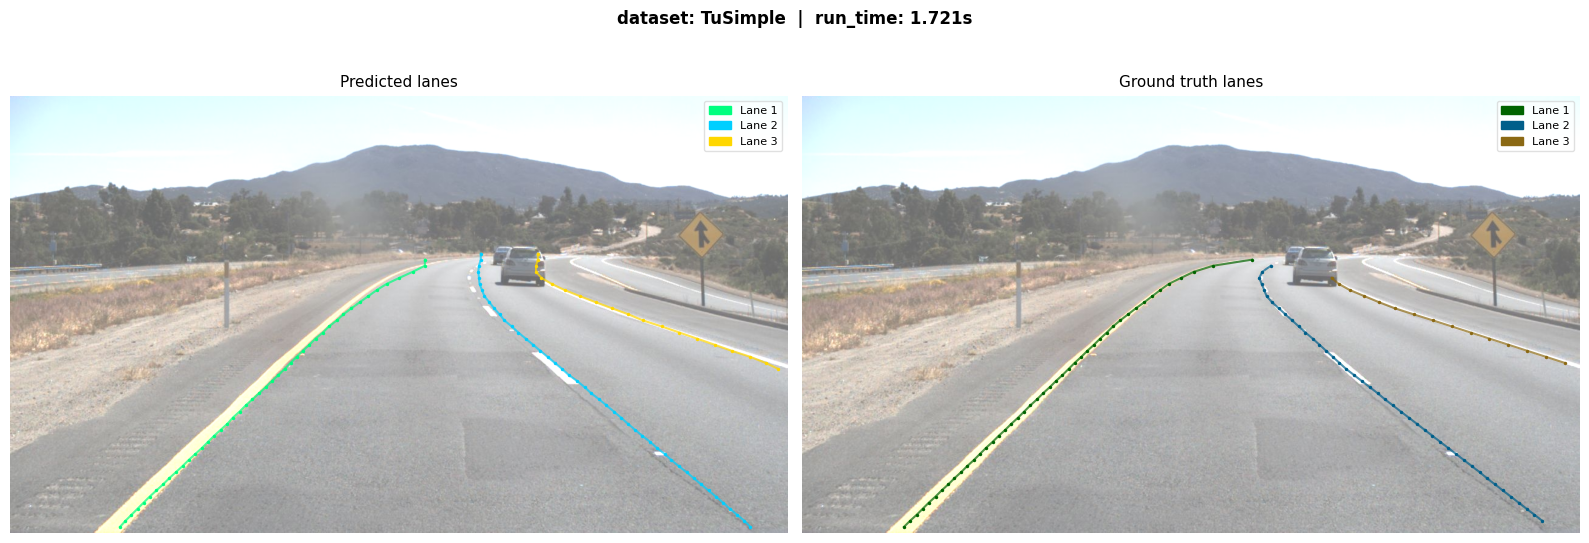

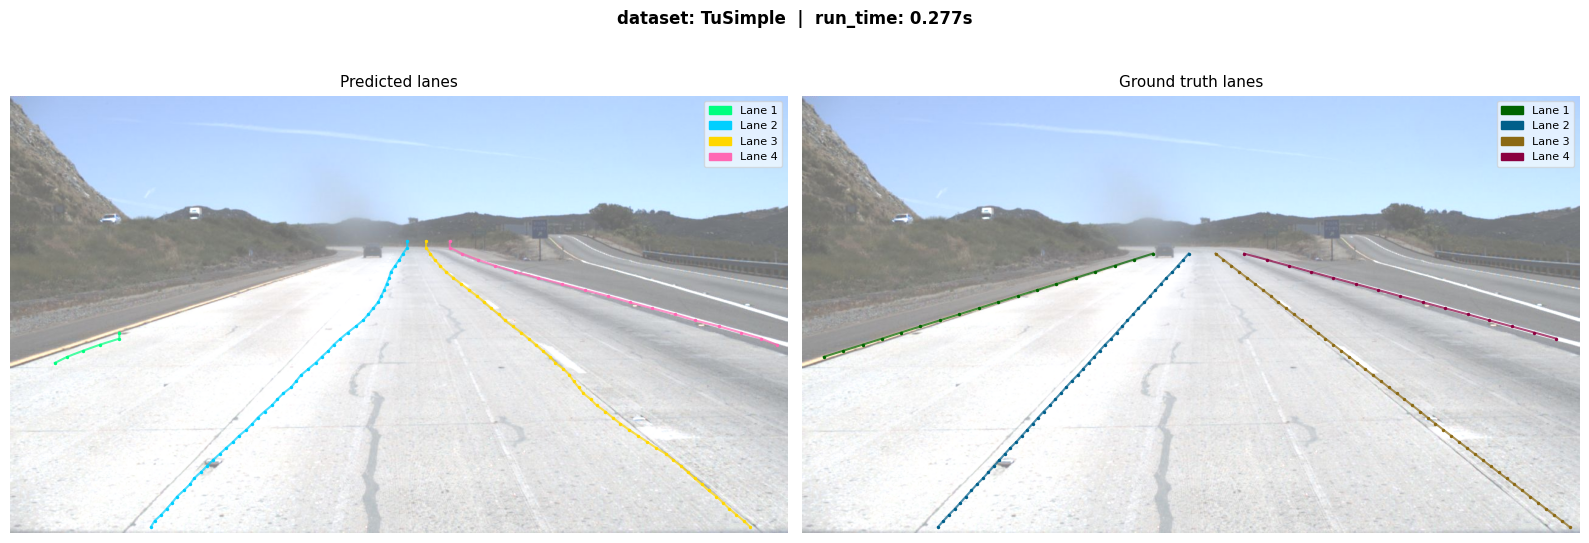

In [10]:
for index, testing_example in enumerate(tqdm(data)):        

    augmented_image = getattr(auggie, AUGMENTATION_TYPE)(testing_example)
    
    response: Prediction = model.predict(augmented_image)
        
    experiment.store_prediction(response)

    if index in numbers:
        
        experiment.visualize_prediction(response)
    
    if (index % 100 == 0) and (index != 0):
        
        print(f"Routine Container Restart for Addressing Memory Leak [{int(index/100)}]")
        
        model.restart(
            
            model.container_id
        )